# Exploratory clustering

In this notebook, we explore different clustering models. Ultimately, we refine and settle on two different models - one with K=2 and the other with K=4.

### Setup

In [23]:
# ------------------------------
# 0. Setup
# ------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
import random
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
import joblib
from sklearn.manifold import TSNE
from tqdm import tqdm

# Load processed ERA5 data
file_path = "../processed/era5_features.csv"
df = pd.read_csv(file_path)

### Feature Selection

In [24]:
# ------------------------------
# 1. Feature Selection
# ------------------------------
features_to_cluster = [
    'min_p_cent', 
    'max_p_grad', 
    'max_radius', 
    'max_uv',
    'fraction_of_time_in_GLR', 
    'maturity_glr0_minus_genesis_ratio'
]

X_scaled = df[features_to_cluster].dropna().copy()

In [25]:
# ------------------------------
# 2. Subsampling & GMM Clustering
# ------------------------------
n_subsamples = 30
sample_frac = 0.8
k_range = range(2, 6)

results = []

for k in k_range:
    for _ in range(n_subsamples):
        sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
        X_sample = X_scaled.iloc[sample_idx]

        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=5)
        labels = gmm.fit_predict(X_sample)

        sil = silhouette_score(X_sample, labels)
        log_likelihood = gmm.score(X_sample) * len(X_sample)
        bic = gmm.bic(X_sample)
        aic = gmm.aic(X_sample)

        results.append({
            "K": k,
            "silhouette": sil,
            "log_likelihood": log_likelihood,
            "bic": bic,
            "aic": aic
        })

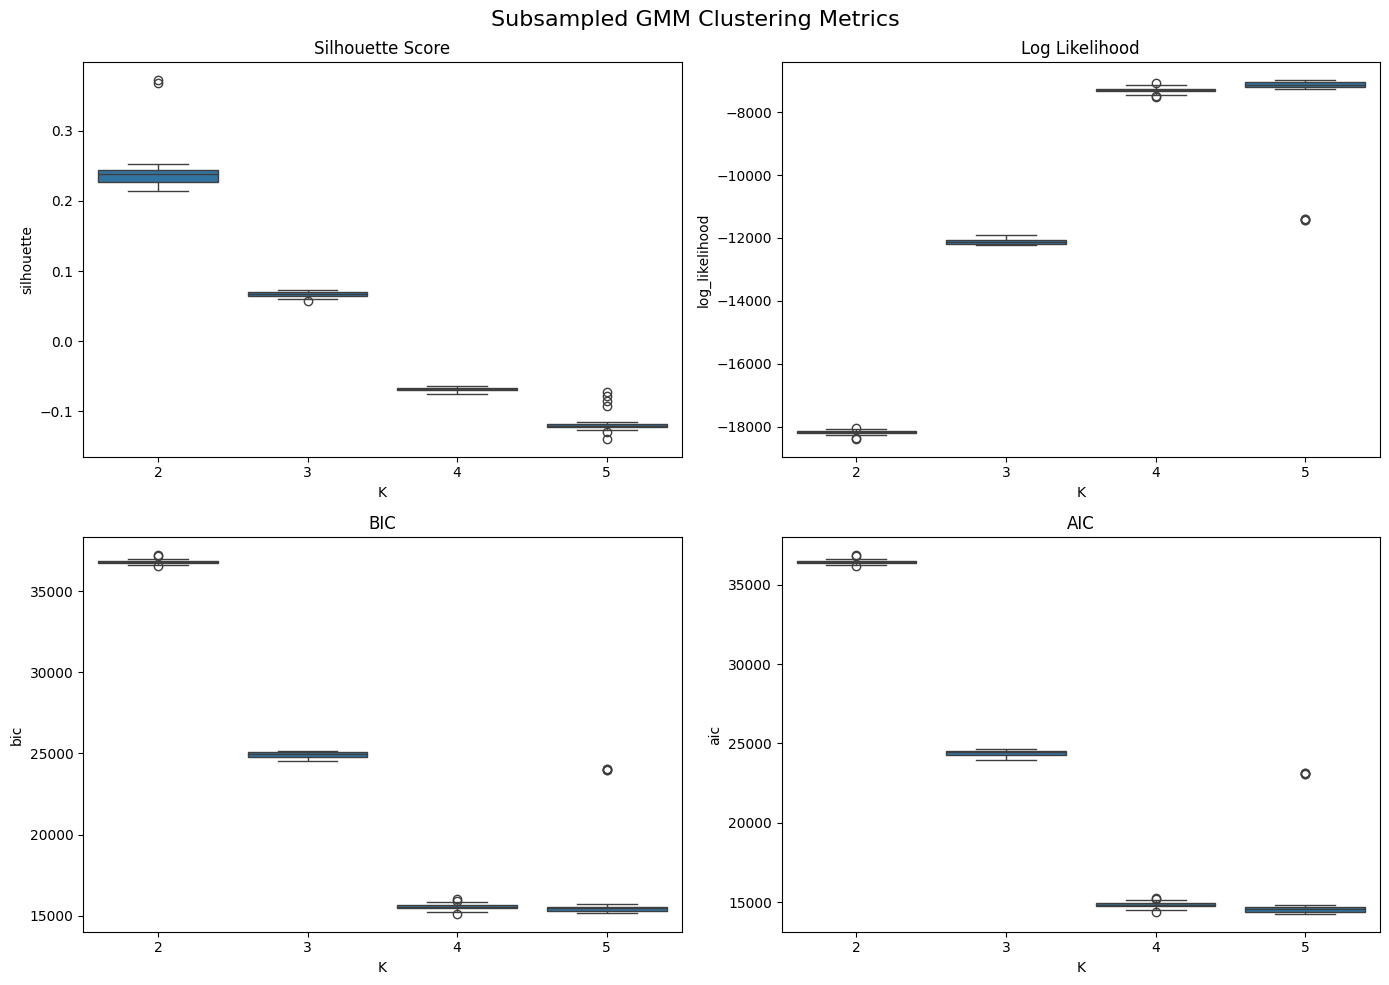

In [26]:
# ------------------------------
# 3. Visualize Metrics
# ------------------------------
metrics_df = pd.DataFrame(results)

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=metrics_df, x="K", y="silhouette", ax=axs[0, 0])
axs[0, 0].set_title("Silhouette Score")
sns.boxplot(data=metrics_df, x="K", y="log_likelihood", ax=axs[0, 1])
axs[0, 1].set_title("Log Likelihood")
sns.boxplot(data=metrics_df, x="K", y="bic", ax=axs[1, 0])
axs[1, 0].set_title("BIC")
sns.boxplot(data=metrics_df, x="K", y="aic", ax=axs[1, 1])
axs[1, 1].set_title("AIC")

plt.suptitle("Subsampled GMM Clustering Metrics", fontsize=16)
plt.tight_layout()
plt.show()

# Developing the K=2 Model

Stability K=2: 100%|██████████| 30/30 [00:03<00:00,  9.82it/s]


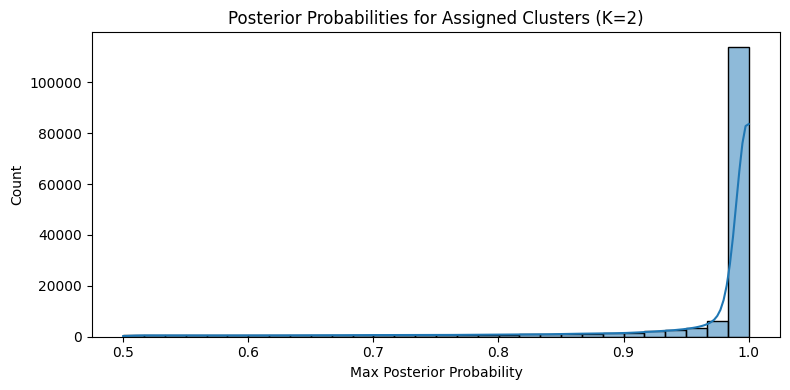

In [27]:
# ------------------------------
# 4. Cluster Stability at K=2
# ------------------------------
k_best = 2
label_matrix_k2 = []
posterior_probs_k2 = []
subsample_indices_k2 = []

for _ in tqdm(range(n_subsamples), desc=f"Stability K={k_best}"):
    sample_idx = random.sample(range(len(X_scaled)), int(sample_frac * len(X_scaled)))
    X_sample = X_scaled.iloc[sample_idx]

    gmm_k2 = GaussianMixture(n_components=k_best, covariance_type='full', random_state=42, n_init=5)
    gmm_k2.fit(X_sample)
    probs_k2 = gmm_k2.predict_proba(X_sample)
    labels_k2 = gmm_k2.predict(X_sample)

    label_matrix_k2.append(labels_k2)
    posterior_probs_k2.append(probs_k2.max(axis=1))
    subsample_indices_k2.append(sample_idx)

# Plot histogram of posterior max probabilities
plt.figure(figsize=(8, 4))
all_probs_k2 = np.concatenate(posterior_probs_k2)
sns.histplot(all_probs_k2, bins=30, kde=True)
plt.title(f"Posterior Probabilities for Assigned Clusters (K={k_best})")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()

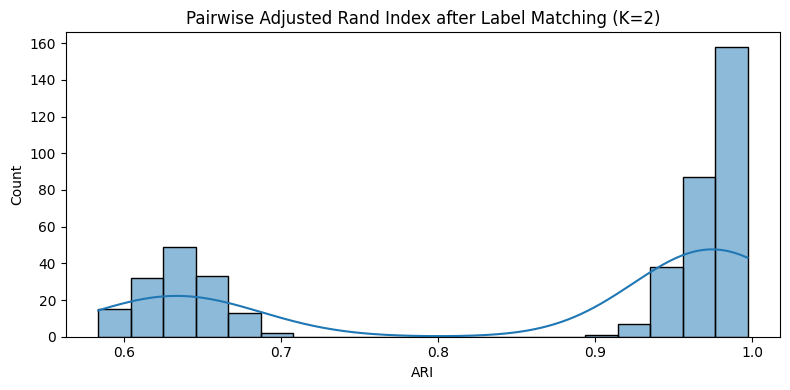

In [28]:
# ------------------------------
# 5. Cluster Label Agreement (Hungarian-matched ARI, K=2)
# ------------------------------
def match_labels(labels1, labels2, n_clusters):
    cost_matrix = np.zeros((n_clusters, n_clusters))
    for i in range(n_clusters):
        for j in range(n_clusters):
            cost_matrix[i, j] = -np.sum((labels1 == i) & (labels2 == j))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    label_map = {j: i for i, j in zip(row_ind, col_ind)}
    matched = np.array([label_map[label] for label in labels2])
    return matched

n_runs = len(label_matrix_k2)
mapped_ari_scores_k2 = []

for i in range(n_runs):
    for j in range(i + 1, n_runs):
        idx_i = subsample_indices_k2[i]
        idx_j = subsample_indices_k2[j]
        shared_idx = list(set(idx_i) & set(idx_j))
        if not shared_idx:
            continue
        idx_i_map = [idx_i.index(x) for x in shared_idx]
        idx_j_map = [idx_j.index(x) for x in shared_idx]
        labels_i = label_matrix_k2[i][idx_i_map]
        labels_j = label_matrix_k2[j][idx_j_map]
        labels_j_matched = match_labels(labels_i, labels_j, k_best)
        ari = adjusted_rand_score(labels_i, labels_j_matched)
        mapped_ari_scores_k2.append(ari)

plt.figure(figsize=(8, 4))
sns.histplot(mapped_ari_scores_k2, bins=20, kde=True)
plt.title(f"Pairwise Adjusted Rand Index after Label Matching (K={k_best})")
plt.xlabel("ARI")
plt.tight_layout()
plt.show()

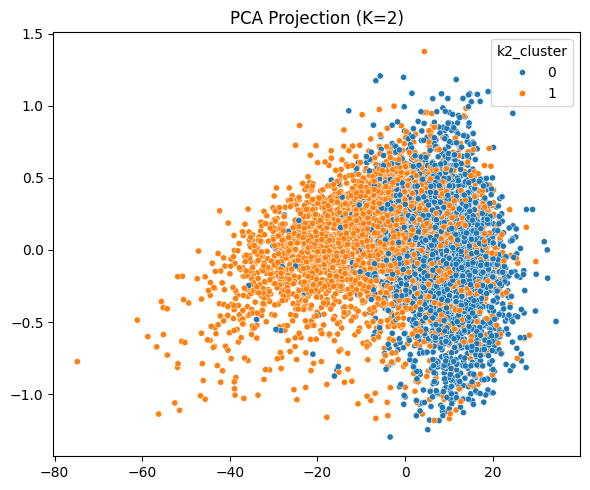

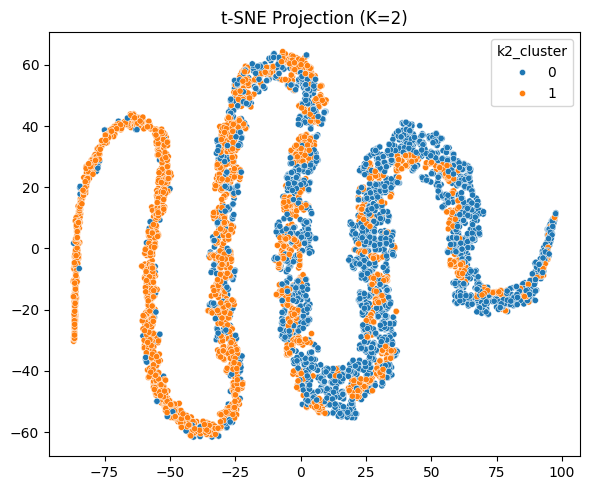

In [29]:
# ------------------------------
# 6. PCA, t-SNE, and UMAP for K=2
# ------------------------------
# Fit on full dataset for K=2
final_gmm_k2 = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
final_gmm_k2.fit(X_scaled)
df['k2_cluster'] = final_gmm_k2.predict(X_scaled)
df['k2_posterior'] = final_gmm_k2.predict_proba(X_scaled).max(axis=1)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
plt.title("PCA Projection (K=2)")
plt.tight_layout()
plt.show()

# t-SNE
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
plt.title("t-SNE Projection (K=2)")
plt.tight_layout()
plt.show()

# UMAP
#umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
#X_umap = umap_model.fit_transform(X_scaled)
#plt.figure(figsize=(6, 5))
#sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=df['k2_cluster'], palette='tab10', s=20)
#plt.title("UMAP Projection (K=2)")
#plt.tight_layout()
#plt.show()

Using 5272 high-confidence points out of 6136 total.


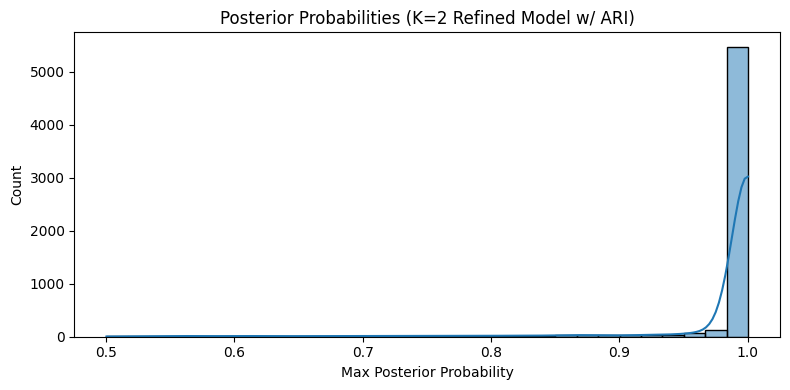

In [30]:
# ------------------------------
# 7. Retrain K=2 on High-Confidence Points
# ------------------------------
confidence_thresh_k2 = 0.95
ari_thresh_k2 = 0.85

# Build ARI mask from earlier analysis
ari_mask_k2 = np.zeros(len(X_scaled), dtype=bool)
for idx_set, probs in zip(subsample_indices_k2, posterior_probs_k2):
    for i, idx in enumerate(idx_set):
        if probs[i] >= confidence_thresh_k2:
            ari_mask_k2[idx] = True

# Combine posterior and ARI masks
confident_mask_k2 = (df['k2_posterior'] >= confidence_thresh_k2) & ari_mask_k2

print(f"Using {confident_mask_k2.sum()} high-confidence points out of {len(df)} total.")

# Fit new GMM on confident data only
X_conf_k2 = X_scaled[confident_mask_k2]
gmm_k2_refined = GaussianMixture(n_components=2, covariance_type='full', random_state=42, n_init=5)
gmm_k2_refined.fit(X_conf_k2)

# Predict labels and posteriors for all data
df['k2_refined_cluster'] = gmm_k2_refined.predict(X_scaled)
df['k2_refined_posterior'] = gmm_k2_refined.predict_proba(X_scaled).max(axis=1)

# Plot refined posteriors
plt.figure(figsize=(8, 4))
sns.histplot(df['k2_refined_posterior'], bins=30, kde=True)
plt.title("Posterior Probabilities (K=2 Refined Model w/ ARI)")
plt.xlabel("Max Posterior Probability")
plt.tight_layout()
plt.show()


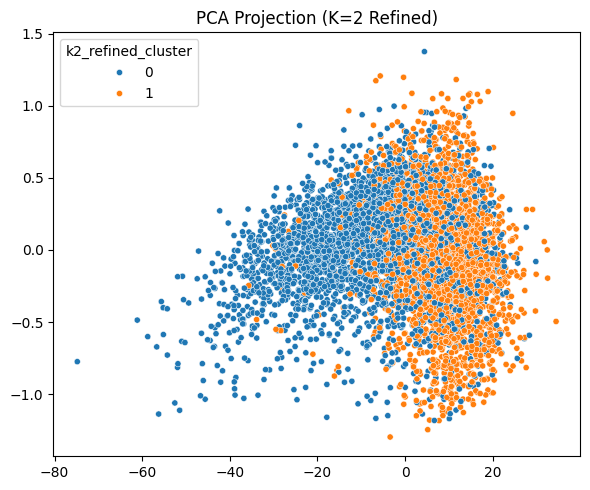

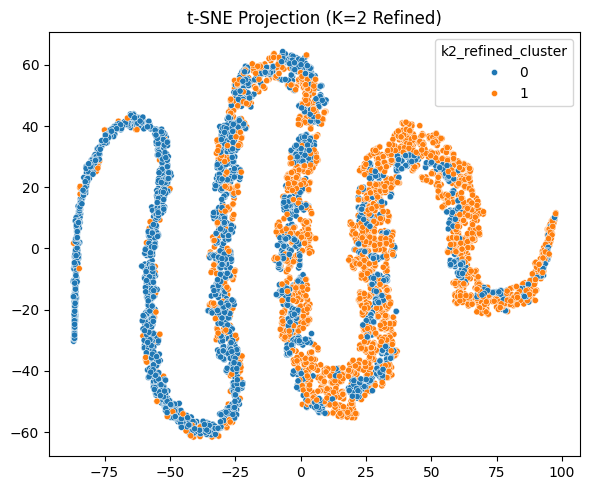

In [31]:
# ------------------------------
# 8. PCA, t-SNE, and UMAP (Refined K=2)
# ------------------------------
# PCA
X_pca_refined = pca.fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca_refined[:, 0], y=X_pca_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
plt.title("PCA Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

# t-SNE
X_tsne_refined = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_tsne_refined[:, 0], y=X_tsne_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
plt.title("t-SNE Projection (K=2 Refined)")
plt.tight_layout()
plt.show()

# UMAP
#X_umap_refined = umap_model.fit_transform(X_scaled)
#plt.figure(figsize=(6, 5))
#sns.scatterplot(x=X_umap_refined[:, 0], y=X_umap_refined[:, 1], hue=df['k2_refined_cluster'], palette='tab10', s=20)
#plt.title("UMAP Projection (K=2 Refined)")
#plt.tight_layout()
#plt.show()

# Developing the K=4 Model